# 第二十七章：AlphaFold 2 關鍵組件實作

本 notebook 實作 AlphaFold 2 的核心組件，包括：
1. 胺基酸編碼與 Embedding
2. MSA 行注意力與列注意力
3. 三角形更新（Triangle Update）
4. Invariant Point Attention (IPA)
5. FAPE 損失函數

**注意**：完整的 AlphaFold 2 實作非常複雜，這裡只展示核心概念的簡化版本。

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch 版本: {torch.__version__}")

PyTorch 版本: 2.9.0+cu126


## 1. 胺基酸編碼

蛋白質由 20 種標準胺基酸組成，加上一個表示間隙或未知的特殊符號。

In [18]:
# 20 種標準胺基酸 + 1 個未知符號
AMINO_ACIDS = 'ACDEFGHIKLMNPQRSTVWY-'
AA_TO_IDX = {aa: idx for idx, aa in enumerate(AMINO_ACIDS)}
NUM_AA = len(AMINO_ACIDS)  # 21

def encode_sequence(sequence: str) -> torch.Tensor:
    """將胺基酸序列轉換為整數編碼"""
    indices = [AA_TO_IDX.get(aa, AA_TO_IDX['-']) for aa in sequence.upper()]
    return torch.tensor(indices, dtype=torch.long)

# 測試
test_seq = "MVLSPADKTNVKAAWGKVGAHAGEYGAEALERMFLSFPTTKTYFPHFDLSH"
encoded = encode_sequence(test_seq)
print(f"序列長度: {len(test_seq)}")
print(f"編碼形狀: {encoded.shape}")
print(f"前 10 個編碼: {encoded[:10]}")

序列長度: 51
編碼形狀: torch.Size([51])
前 10 個編碼: tensor([10, 17,  9, 15, 12,  0,  2,  8, 16, 11])


## 2. 輸入 Embedding

AlphaFold 2 使用兩種主要的表示：
- **MSA 表示**：形狀為 (num_seqs, num_residues, channels)
- **Pair 表示**：形狀為 (num_residues, num_residues, channels)

In [19]:
class InputEmbedding(nn.Module):
    """
    AlphaFold 2 的輸入嵌入層
    將胺基酸序列和 MSA 轉換為初始的 MSA 表示和 Pair 表示
    """
    def __init__(
        self,
        num_aa: int = 21,
        msa_dim: int = 256,
        pair_dim: int = 128,
        max_seq_len: int = 512
    ):
        super().__init__()
        
        # MSA embedding
        self.aa_embedding = nn.Embedding(num_aa, msa_dim)
        self.position_embedding = nn.Embedding(max_seq_len, msa_dim)
        
        # Pair embedding - 使用相對位置編碼
        self.relative_position_embedding = nn.Embedding(2 * max_seq_len - 1, pair_dim)
        
        # 從 MSA 投影到 Pair 的初始表示
        self.msa_to_pair_left = nn.Linear(msa_dim, pair_dim)
        self.msa_to_pair_right = nn.Linear(msa_dim, pair_dim)
        
        self.max_seq_len = max_seq_len
        
    def forward(self, msa: torch.Tensor) -> tuple:
        """
        Args:
            msa: (batch, num_seqs, seq_len) 整數編碼的 MSA
            
        Returns:
            msa_repr: (batch, num_seqs, seq_len, msa_dim)
            pair_repr: (batch, seq_len, seq_len, pair_dim)
        """
        batch_size, num_seqs, seq_len = msa.shape
        device = msa.device
        
        # MSA 表示
        positions = torch.arange(seq_len, device=device).unsqueeze(0).unsqueeze(0)
        msa_repr = self.aa_embedding(msa) + self.position_embedding(positions)
        
        # Pair 表示 - 使用第一條序列（target sequence）
        target_repr = msa_repr[:, 0]  # (batch, seq_len, msa_dim)
        
        # 計算 Pair 表示
        left = self.msa_to_pair_left(target_repr)  # (batch, seq_len, pair_dim)
        right = self.msa_to_pair_right(target_repr)
        
        # Outer sum: (batch, seq_len, 1, pair_dim) + (batch, 1, seq_len, pair_dim)
        pair_repr = left.unsqueeze(2) + right.unsqueeze(1)
        
        # 加入相對位置編碼
        positions_i = torch.arange(seq_len, device=device).unsqueeze(1)
        positions_j = torch.arange(seq_len, device=device).unsqueeze(0)
        relative_positions = positions_i - positions_j + self.max_seq_len - 1
        relative_positions = relative_positions.clamp(0, 2 * self.max_seq_len - 2)
        
        pair_repr = pair_repr + self.relative_position_embedding(relative_positions)
        
        return msa_repr, pair_repr

# 測試
embedding = InputEmbedding()
test_msa = torch.randint(0, 21, (2, 128, 64))  # batch=2, 128 sequences, length=64
msa_repr, pair_repr = embedding(test_msa)
print(f"MSA 表示形狀: {msa_repr.shape}")  # (2, 128, 64, 256)
print(f"Pair 表示形狀: {pair_repr.shape}")  # (2, 64, 64, 128)

MSA 表示形狀: torch.Size([2, 128, 64, 256])
Pair 表示形狀: torch.Size([2, 64, 64, 128])


## 3. MSA 行注意力（Row-wise Attention）

MSA 行注意力讓同一殘基位置在不同序列之間交換資訊，這對於捕捉共演化信號至關重要。

In [20]:
class MSARowAttention(nn.Module):
    """
    MSA 行注意力：對每個殘基位置，在不同序列之間做注意力
    這讓模型學習殘基在演化上的相關性
    """
    def __init__(
        self,
        msa_dim: int = 256,
        pair_dim: int = 128,
        num_heads: int = 8,
        dropout: float = 0.1
    ):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = msa_dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        self.norm = nn.LayerNorm(msa_dim)
        
        # Q, K, V 投影
        self.to_qkv = nn.Linear(msa_dim, 3 * msa_dim, bias=False)
        
        # Pair bias - 用 pair 表示來調整注意力
        self.pair_bias = nn.Linear(pair_dim, num_heads, bias=False)
        
        # 輸出投影
        self.to_out = nn.Sequential(
            nn.Linear(msa_dim, msa_dim),
            nn.Dropout(dropout)
        )
        
    def forward(self, msa: torch.Tensor, pair: torch.Tensor) -> torch.Tensor:
        """
        Args:
            msa: (batch, num_seqs, seq_len, msa_dim)
            pair: (batch, seq_len, seq_len, pair_dim)
            
        Returns:
            (batch, num_seqs, seq_len, msa_dim)
        """
        batch, num_seqs, seq_len, _ = msa.shape
        
        # Layer Norm
        msa = self.norm(msa)
        
        # QKV
        qkv = self.to_qkv(msa)  # (batch, num_seqs, seq_len, 3*msa_dim)
        q, k, v = qkv.chunk(3, dim=-1)
        
        # 重塑為多頭格式
        # 對於行注意力，我們在 num_seqs 維度上做注意力
        q = q.view(batch, num_seqs, seq_len, self.num_heads, self.head_dim)
        k = k.view(batch, num_seqs, seq_len, self.num_heads, self.head_dim)
        v = v.view(batch, num_seqs, seq_len, self.num_heads, self.head_dim)
        
        # 調整維度順序
        q = q.permute(0, 2, 3, 1, 4)  # (batch, seq_len, heads, num_seqs, head_dim)
        k = k.permute(0, 2, 3, 1, 4)
        v = v.permute(0, 2, 3, 1, 4)
        
        # 計算注意力分數
        attn = torch.einsum('blhid,blhjd->blhij', q, k) * self.scale
        # attn: (batch, seq_len, heads, num_seqs, num_seqs)
        
        # 加入 pair bias（可選，這裡簡化處理）
        # 實際 AlphaFold 2 中 pair bias 的使用更複雜
        
        attn = F.softmax(attn, dim=-1)
        
        # 應用注意力到 V
        out = torch.einsum('blhij,blhjd->blhid', attn, v)
        # out: (batch, seq_len, heads, num_seqs, head_dim)
        
        # 重塑回原始格式
        out = out.permute(0, 3, 1, 2, 4)  # (batch, num_seqs, seq_len, heads, head_dim)
        out = out.reshape(batch, num_seqs, seq_len, -1)
        
        return self.to_out(out)

# 測試
row_attn = MSARowAttention()
output = row_attn(msa_repr, pair_repr)
print(f"MSA 行注意力輸出形狀: {output.shape}")

MSA 行注意力輸出形狀: torch.Size([2, 128, 64, 256])


## 4. MSA 列注意力（Column-wise Attention）

MSA 列注意力讓同一序列中不同殘基位置之間交換資訊。

In [21]:
class MSAColumnAttention(nn.Module):
    """
    MSA 列注意力：對每條序列，在不同殘基位置之間做注意力
    這讓模型學習序列內部的長程依賴
    """
    def __init__(
        self,
        msa_dim: int = 256,
        num_heads: int = 8,
        dropout: float = 0.1
    ):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = msa_dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        self.norm = nn.LayerNorm(msa_dim)
        self.to_qkv = nn.Linear(msa_dim, 3 * msa_dim, bias=False)
        self.to_out = nn.Sequential(
            nn.Linear(msa_dim, msa_dim),
            nn.Dropout(dropout)
        )
        
    def forward(self, msa: torch.Tensor) -> torch.Tensor:
        """
        Args:
            msa: (batch, num_seqs, seq_len, msa_dim)
            
        Returns:
            (batch, num_seqs, seq_len, msa_dim)
        """
        batch, num_seqs, seq_len, _ = msa.shape
        
        msa = self.norm(msa)
        
        # QKV
        qkv = self.to_qkv(msa)
        q, k, v = qkv.chunk(3, dim=-1)
        
        # 重塑為多頭格式
        # 對於列注意力，我們在 seq_len 維度上做注意力
        q = q.view(batch, num_seqs, seq_len, self.num_heads, self.head_dim)
        k = k.view(batch, num_seqs, seq_len, self.num_heads, self.head_dim)
        v = v.view(batch, num_seqs, seq_len, self.num_heads, self.head_dim)
        
        # 調整維度順序
        q = q.permute(0, 1, 3, 2, 4)  # (batch, num_seqs, heads, seq_len, head_dim)
        k = k.permute(0, 1, 3, 2, 4)
        v = v.permute(0, 1, 3, 2, 4)
        
        # 計算注意力
        attn = torch.einsum('bnhid,bnhjd->bnhij', q, k) * self.scale
        attn = F.softmax(attn, dim=-1)
        
        # 應用注意力
        out = torch.einsum('bnhij,bnhjd->bnhid', attn, v)
        out = out.permute(0, 1, 3, 2, 4)  # (batch, num_seqs, seq_len, heads, head_dim)
        out = out.reshape(batch, num_seqs, seq_len, -1)
        
        return self.to_out(out)

# 測試
col_attn = MSAColumnAttention()
output = col_attn(msa_repr)
print(f"MSA 列注意力輸出形狀: {output.shape}")

MSA 列注意力輸出形狀: torch.Size([2, 128, 64, 256])


## 5. Outer Product Mean

將 MSA 表示的資訊傳遞到 Pair 表示中。

In [22]:
class OuterProductMean(nn.Module):
    """
    Outer Product Mean：從 MSA 表示計算 Pair 表示的更新
    這是將序列資訊轉換為殘基對資訊的關鍵步驟
    """
    def __init__(
        self,
        msa_dim: int = 256,
        pair_dim: int = 128,
        hidden_dim: int = 32
    ):
        super().__init__()
        
        self.norm = nn.LayerNorm(msa_dim)
        self.linear_a = nn.Linear(msa_dim, hidden_dim)
        self.linear_b = nn.Linear(msa_dim, hidden_dim)
        self.linear_out = nn.Linear(hidden_dim * hidden_dim, pair_dim)
        
    def forward(self, msa: torch.Tensor) -> torch.Tensor:
        """
        Args:
            msa: (batch, num_seqs, seq_len, msa_dim)
            
        Returns:
            (batch, seq_len, seq_len, pair_dim)
        """
        msa = self.norm(msa)
        
        # 投影到較低維度
        a = self.linear_a(msa)  # (batch, num_seqs, seq_len, hidden_dim)
        b = self.linear_b(msa)
        
        # 計算 outer product 並在序列維度上取平均
        # a_i ⊗ b_j 得到 pair (i, j) 的特徵
        outer = torch.einsum('bsic,bsjd->bijcd', a, b)  # (batch, seq_len, seq_len, h, h)
        batch, seq_len, _, h, _ = outer.shape
        
        # 使用 reshape 而非 view（因為 einsum 後 tensor 可能不是 contiguous）
        outer = outer.reshape(batch, seq_len, seq_len, h * h)
        
        # 投影到 pair_dim
        return self.linear_out(outer)

# 測試
opm = OuterProductMean()
pair_update = opm(msa_repr)
print(f"Outer Product Mean 輸出形狀: {pair_update.shape}")

Outer Product Mean 輸出形狀: torch.Size([2, 64, 64, 128])


## 6. 三角形更新（Triangle Updates）

三角形更新是 AlphaFold 2 的核心創新之一，它利用三角不等式約束來傳播 Pair 表示中的資訊。

如果殘基 i 和 j 距離近，且 j 和 k 距離近，那麼 i 和 k 也應該距離近。

In [23]:
class TriangleMultiplicationOutgoing(nn.Module):
    """
    三角形乘法更新（Outgoing edges）
    更新規則：z'_ij = z_ij + Σ_k (a_ik ⊙ b_kj)
    """
    def __init__(self, pair_dim: int = 128, hidden_dim: int = 64):
        super().__init__()
        
        self.norm = nn.LayerNorm(pair_dim)
        self.norm_out = nn.LayerNorm(hidden_dim)
        
        # 左邊和右邊的投影
        self.linear_a = nn.Linear(pair_dim, hidden_dim)
        self.linear_b = nn.Linear(pair_dim, hidden_dim)
        
        # 門控
        self.gate_a = nn.Linear(pair_dim, hidden_dim)
        self.gate_b = nn.Linear(pair_dim, hidden_dim)
        
        # 輸出投影
        self.linear_out = nn.Linear(hidden_dim, pair_dim)
        self.gate_out = nn.Linear(pair_dim, pair_dim)
        
    def forward(self, pair: torch.Tensor) -> torch.Tensor:
        """
        Args:
            pair: (batch, seq_len, seq_len, pair_dim)
            
        Returns:
            (batch, seq_len, seq_len, pair_dim)
        """
        pair_normed = self.norm(pair)
        
        # 計算帶門控的 a 和 b
        a = self.linear_a(pair_normed) * torch.sigmoid(self.gate_a(pair_normed))
        b = self.linear_b(pair_normed) * torch.sigmoid(self.gate_b(pair_normed))
        
        # 三角形更新：對於 outgoing，我們累加 a_ik * b_kj
        # 這相當於矩陣乘法 a @ b^T
        out = torch.einsum('bikc,bkjc->bijc', a, b)
        
        out = self.norm_out(out)
        out = self.linear_out(out)
        
        # 輸出門控
        gate = torch.sigmoid(self.gate_out(pair_normed))
        
        return out * gate

# 測試
tri_out = TriangleMultiplicationOutgoing()
pair_update = tri_out(pair_repr)
print(f"三角形更新（Outgoing）輸出形狀: {pair_update.shape}")

三角形更新（Outgoing）輸出形狀: torch.Size([2, 64, 64, 128])


In [24]:
class TriangleMultiplicationIncoming(nn.Module):
    """
    三角形乘法更新（Incoming edges）
    更新規則：z'_ij = z_ij + Σ_k (a_ki ⊙ b_kj)
    """
    def __init__(self, pair_dim: int = 128, hidden_dim: int = 64):
        super().__init__()
        
        self.norm = nn.LayerNorm(pair_dim)
        self.norm_out = nn.LayerNorm(hidden_dim)
        
        self.linear_a = nn.Linear(pair_dim, hidden_dim)
        self.linear_b = nn.Linear(pair_dim, hidden_dim)
        self.gate_a = nn.Linear(pair_dim, hidden_dim)
        self.gate_b = nn.Linear(pair_dim, hidden_dim)
        
        self.linear_out = nn.Linear(hidden_dim, pair_dim)
        self.gate_out = nn.Linear(pair_dim, pair_dim)
        
    def forward(self, pair: torch.Tensor) -> torch.Tensor:
        pair_normed = self.norm(pair)
        
        a = self.linear_a(pair_normed) * torch.sigmoid(self.gate_a(pair_normed))
        b = self.linear_b(pair_normed) * torch.sigmoid(self.gate_b(pair_normed))
        
        # 三角形更新：對於 incoming，我們累加 a_ki * b_kj
        # 這相當於 a^T @ b
        out = torch.einsum('bkic,bkjc->bijc', a, b)
        
        out = self.norm_out(out)
        out = self.linear_out(out)
        
        gate = torch.sigmoid(self.gate_out(pair_normed))
        
        return out * gate

# 測試
tri_in = TriangleMultiplicationIncoming()
pair_update = tri_in(pair_repr)
print(f"三角形更新（Incoming）輸出形狀: {pair_update.shape}")

三角形更新（Incoming）輸出形狀: torch.Size([2, 64, 64, 128])


## 7. 三角形注意力（Triangle Attention）

除了三角形乘法更新，AlphaFold 2 還使用三角形注意力來傳播資訊。

In [25]:
class TriangleAttention(nn.Module):
    """
    三角形注意力：在 Pair 表示上做注意力
    starting_node=True: 對於固定的 i，在 j 上做注意力
    starting_node=False: 對於固定的 j，在 i 上做注意力
    """
    def __init__(
        self,
        pair_dim: int = 128,
        num_heads: int = 4,
        starting_node: bool = True
    ):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = pair_dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.starting_node = starting_node
        
        self.norm = nn.LayerNorm(pair_dim)
        self.to_qkv = nn.Linear(pair_dim, 3 * pair_dim, bias=False)
        
        # Bias from pair representation
        self.bias = nn.Linear(pair_dim, num_heads, bias=False)
        
        # Gate and output
        self.gate = nn.Linear(pair_dim, pair_dim)
        self.to_out = nn.Linear(pair_dim, pair_dim)
        
    def forward(self, pair: torch.Tensor) -> torch.Tensor:
        """
        Args:
            pair: (batch, seq_len, seq_len, pair_dim)
            
        Returns:
            (batch, seq_len, seq_len, pair_dim)
        """
        if not self.starting_node:
            pair = pair.transpose(1, 2)
            
        batch, seq_len_i, seq_len_j, _ = pair.shape
        
        pair_normed = self.norm(pair)
        
        # QKV
        qkv = self.to_qkv(pair_normed)
        q, k, v = qkv.chunk(3, dim=-1)
        
        # 重塑為多頭格式
        q = q.view(batch, seq_len_i, seq_len_j, self.num_heads, self.head_dim)
        k = k.view(batch, seq_len_i, seq_len_j, self.num_heads, self.head_dim)
        v = v.view(batch, seq_len_i, seq_len_j, self.num_heads, self.head_dim)
        
        # 對於 starting_node，我們固定 i，在 j 上做注意力
        q = q.permute(0, 1, 3, 2, 4)  # (batch, i, heads, j, head_dim)
        k = k.permute(0, 1, 3, 2, 4)
        v = v.permute(0, 1, 3, 2, 4)
        
        # 計算注意力
        attn = torch.einsum('bihkd,bihjd->bihkj', q, k) * self.scale
        
        # 加入 bias
        bias = self.bias(pair_normed)  # (batch, i, j, heads)
        bias = bias.permute(0, 1, 3, 2).unsqueeze(-1)  # (batch, i, heads, j, 1)
        attn = attn + bias.transpose(-1, -2)
        
        attn = F.softmax(attn, dim=-1)
        
        # 應用注意力
        out = torch.einsum('bihkj,bihjd->bihkd', attn, v)
        out = out.permute(0, 1, 3, 2, 4)  # (batch, i, j, heads, head_dim)
        out = out.reshape(batch, seq_len_i, seq_len_j, -1)
        
        # 門控輸出
        gate = torch.sigmoid(self.gate(pair_normed))
        out = self.to_out(out) * gate
        
        if not self.starting_node:
            out = out.transpose(1, 2)
            
        return out

# 測試
tri_attn_start = TriangleAttention(starting_node=True)
tri_attn_end = TriangleAttention(starting_node=False)

out_start = tri_attn_start(pair_repr)
out_end = tri_attn_end(pair_repr)
print(f"三角形注意力（Starting）輸出形狀: {out_start.shape}")
print(f"三角形注意力（Ending）輸出形狀: {out_end.shape}")

三角形注意力（Starting）輸出形狀: torch.Size([2, 64, 64, 128])
三角形注意力（Ending）輸出形狀: torch.Size([2, 64, 64, 128])


## 8. Invariant Point Attention (IPA)

IPA 是 Structure Module 的核心組件。它對 3D 空間中的剛體變換保持不變性。

In [26]:
class InvariantPointAttention(nn.Module):
    """
    不變點注意力（Invariant Point Attention）
    
    這是 AlphaFold 2 Structure Module 的核心。
    它結合了三種類型的資訊：
    1. 序列表示（類似標準 attention）
    2. Pair 表示（殘基對的相互作用）
    3. 3D 點（在局部座標系中定義的點）
    
    關鍵特性：對全域剛體變換不變
    """
    def __init__(
        self,
        single_dim: int = 384,
        pair_dim: int = 128,
        num_heads: int = 12,
        num_qk_points: int = 4,
        num_v_points: int = 8
    ):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = single_dim // num_heads
        self.num_qk_points = num_qk_points
        self.num_v_points = num_v_points
        self.pair_dim = pair_dim
        
        # 標準 attention 的 Q, K, V
        self.to_q = nn.Linear(single_dim, num_heads * self.head_dim, bias=False)
        self.to_k = nn.Linear(single_dim, num_heads * self.head_dim, bias=False)
        self.to_v = nn.Linear(single_dim, num_heads * self.head_dim, bias=False)
        
        # 點的 Q, K, V（3D 座標）
        self.to_q_points = nn.Linear(single_dim, num_heads * num_qk_points * 3, bias=False)
        self.to_k_points = nn.Linear(single_dim, num_heads * num_qk_points * 3, bias=False)
        self.to_v_points = nn.Linear(single_dim, num_heads * num_v_points * 3, bias=False)
        
        # Pair bias
        self.pair_bias = nn.Linear(pair_dim, num_heads, bias=False)
        
        # 可學習的權重係數
        self.head_weights = nn.Parameter(torch.zeros(num_heads))
        
        # 輸出投影
        # out_v: num_heads * head_dim = single_dim
        # out_pts: num_heads * num_v_points * 3 (3D 座標)
        # out_pair: num_heads * pair_dim
        output_dim = single_dim + num_heads * num_v_points * 3 + num_heads * pair_dim
        self.to_out = nn.Linear(output_dim, single_dim)
        
    def forward(
        self,
        single: torch.Tensor,
        pair: torch.Tensor,
        frames: torch.Tensor
    ) -> torch.Tensor:
        """
        Args:
            single: (batch, seq_len, single_dim) - 單一殘基表示
            pair: (batch, seq_len, seq_len, pair_dim) - 殘基對表示
            frames: (batch, seq_len, 4, 4) - 每個殘基的局部座標框架
            
        Returns:
            (batch, seq_len, single_dim)
        """
        batch, seq_len, _ = single.shape
        
        # 1. 標準 attention
        q = self.to_q(single).view(batch, seq_len, self.num_heads, self.head_dim)
        k = self.to_k(single).view(batch, seq_len, self.num_heads, self.head_dim)
        v = self.to_v(single).view(batch, seq_len, self.num_heads, self.head_dim)
        
        # 標準 attention 分數
        attn_qk = torch.einsum('bihd,bjhd->bhij', q, k) / (self.head_dim ** 0.5)
        
        # 2. 點 attention（簡化版本，省略實際的框架變換）
        q_pts = self.to_q_points(single).view(
            batch, seq_len, self.num_heads, self.num_qk_points, 3
        )
        k_pts = self.to_k_points(single).view(
            batch, seq_len, self.num_heads, self.num_qk_points, 3
        )
        
        # 點之間的距離（簡化計算）
        pt_diff = q_pts.unsqueeze(2) - k_pts.unsqueeze(1)  # (batch, i, j, heads, pts, 3)
        pt_dist = (pt_diff ** 2).sum(dim=(-1, -2))  # (batch, i, j, heads)
        attn_pts = -0.5 * pt_dist.permute(0, 3, 1, 2)  # (batch, heads, i, j)
        
        # 3. Pair bias
        pair_bias = self.pair_bias(pair).permute(0, 3, 1, 2)  # (batch, heads, i, j)
        
        # 組合所有 attention 分數
        head_weights = F.softplus(self.head_weights)
        attn = attn_qk + head_weights.view(1, -1, 1, 1) * attn_pts + pair_bias
        attn = F.softmax(attn, dim=-1)
        
        # 應用 attention 到 V
        out_v = torch.einsum('bhij,bjhd->bihd', attn, v)
        out_v = out_v.reshape(batch, seq_len, -1)  # (batch, seq_len, single_dim)
        
        # 應用 attention 到點 V（簡化）
        v_pts = self.to_v_points(single).view(
            batch, seq_len, self.num_heads, self.num_v_points, 3
        )
        out_pts = torch.einsum('bhij,bjhpc->bihpc', attn, v_pts)
        out_pts = out_pts.reshape(batch, seq_len, -1)  # (batch, seq_len, num_heads * num_v_points * 3)
        
        # 從 pair 表示中提取資訊
        out_pair = torch.einsum('bhij,bijc->bihc', attn, pair)
        out_pair = out_pair.reshape(batch, seq_len, -1)  # (batch, seq_len, num_heads * pair_dim)
        
        # 組合所有輸出
        out = torch.cat([out_v, out_pts, out_pair], dim=-1)
        
        return self.to_out(out)

# 測試
ipa = InvariantPointAttention()
single_repr = torch.randn(2, 64, 384)
pair_repr_small = torch.randn(2, 64, 64, 128)
frames = torch.eye(4).unsqueeze(0).unsqueeze(0).expand(2, 64, -1, -1)

output = ipa(single_repr, pair_repr_small, frames)
print(f"IPA 輸出形狀: {output.shape}")

IPA 輸出形狀: torch.Size([2, 64, 384])


## 9. FAPE 損失函數

Frame Aligned Point Error (FAPE) 是 AlphaFold 2 的主要損失函數。

In [27]:
def compute_fape(
    pred_positions: torch.Tensor,
    true_positions: torch.Tensor,
    pred_frames: torch.Tensor,
    true_frames: torch.Tensor,
    clamp_distance: float = 10.0,
    length_scale: float = 10.0
) -> torch.Tensor:
    """
    計算 Frame Aligned Point Error (FAPE)
    
    FAPE 在每個殘基的局部座標系中計算誤差，這使得損失對局部結構敏感
    
    Args:
        pred_positions: (batch, num_residues, 3) 預測的原子位置
        true_positions: (batch, num_residues, 3) 真實的原子位置
        pred_frames: (batch, num_residues, 3, 3) 預測的旋轉矩陣
        true_frames: (batch, num_residues, 3, 3) 真實的旋轉矩陣
        clamp_distance: 截斷距離
        length_scale: 長度尺度
        
    Returns:
        FAPE 損失值
    """
    batch, num_residues, _ = pred_positions.shape
    
    # 對於每個框架 i，計算所有點 j 在框架 i 中的座標差
    # 這是簡化版本，實際實作需要完整的框架變換
    
    # 計算預測和真實位置在每個框架中的相對位置
    # 這裡使用簡化版本：直接計算點對點距離
    
    # 展開計算所有 (frame_i, point_j) 對
    pred_expanded = pred_positions.unsqueeze(1)  # (batch, 1, num_residues, 3)
    true_expanded = true_positions.unsqueeze(1)
    
    # 框架原點（使用每個殘基的位置作為框架原點）
    pred_origins = pred_positions.unsqueeze(2)  # (batch, num_residues, 1, 3)
    true_origins = true_positions.unsqueeze(2)
    
    # 在框架中的相對位置
    pred_rel = pred_expanded - pred_origins  # (batch, num_residues, num_residues, 3)
    true_rel = true_expanded - true_origins
    
    # 計算距離誤差
    diff = pred_rel - true_rel
    dist = torch.sqrt((diff ** 2).sum(dim=-1) + 1e-8)  # (batch, num_residues, num_residues)
    
    # 截斷
    dist = torch.clamp(dist, max=clamp_distance)
    
    # 正規化並取平均
    fape = dist / length_scale
    fape = fape.mean()
    
    return fape

# 測試
pred_pos = torch.randn(2, 64, 3)
true_pos = pred_pos + torch.randn(2, 64, 3) * 0.5  # 加入一些噪音
pred_rot = torch.eye(3).unsqueeze(0).unsqueeze(0).expand(2, 64, -1, -1)
true_rot = pred_rot.clone()

fape_loss = compute_fape(pred_pos, true_pos, pred_rot, true_rot)
print(f"FAPE 損失: {fape_loss.item():.4f}")

FAPE 損失: 0.1088


## 10. 完整的 Evoformer Block

In [28]:
class EvoformerBlock(nn.Module):
    """
    Evoformer Block：同時處理 MSA 和 Pair 表示
    
    每個 block 包含：
    1. MSA row attention（受 pair bias 影響）
    2. MSA column attention
    3. MSA transition
    4. Outer product mean（MSA → Pair）
    5. Triangle multiplication (outgoing)
    6. Triangle multiplication (incoming)
    7. Triangle attention (starting)
    8. Triangle attention (ending)
    9. Pair transition
    """
    def __init__(
        self,
        msa_dim: int = 256,
        pair_dim: int = 128,
        num_heads_msa: int = 8,
        num_heads_pair: int = 4,
        dropout: float = 0.1
    ):
        super().__init__()
        
        # MSA 處理
        self.msa_row_attn = MSARowAttention(msa_dim, pair_dim, num_heads_msa, dropout)
        self.msa_col_attn = MSAColumnAttention(msa_dim, num_heads_msa, dropout)
        self.msa_transition = nn.Sequential(
            nn.LayerNorm(msa_dim),
            nn.Linear(msa_dim, msa_dim * 4),
            nn.ReLU(),
            nn.Linear(msa_dim * 4, msa_dim),
            nn.Dropout(dropout)
        )
        
        # MSA → Pair
        self.outer_product_mean = OuterProductMean(msa_dim, pair_dim)
        
        # Pair 處理
        self.tri_mult_out = TriangleMultiplicationOutgoing(pair_dim)
        self.tri_mult_in = TriangleMultiplicationIncoming(pair_dim)
        self.tri_attn_start = TriangleAttention(pair_dim, num_heads_pair, True)
        self.tri_attn_end = TriangleAttention(pair_dim, num_heads_pair, False)
        self.pair_transition = nn.Sequential(
            nn.LayerNorm(pair_dim),
            nn.Linear(pair_dim, pair_dim * 4),
            nn.ReLU(),
            nn.Linear(pair_dim * 4, pair_dim),
            nn.Dropout(dropout)
        )
        
    def forward(
        self,
        msa: torch.Tensor,
        pair: torch.Tensor
    ) -> tuple:
        """
        Args:
            msa: (batch, num_seqs, seq_len, msa_dim)
            pair: (batch, seq_len, seq_len, pair_dim)
            
        Returns:
            msa: 更新後的 MSA 表示
            pair: 更新後的 Pair 表示
        """
        # MSA 更新
        msa = msa + self.msa_row_attn(msa, pair)
        msa = msa + self.msa_col_attn(msa)
        msa = msa + self.msa_transition(msa)
        
        # MSA → Pair
        pair = pair + self.outer_product_mean(msa)
        
        # Pair 更新
        pair = pair + self.tri_mult_out(pair)
        pair = pair + self.tri_mult_in(pair)
        pair = pair + self.tri_attn_start(pair)
        pair = pair + self.tri_attn_end(pair)
        pair = pair + self.pair_transition(pair)
        
        return msa, pair

# 測試
evoformer = EvoformerBlock()
msa_out, pair_out = evoformer(msa_repr, pair_repr)
print(f"Evoformer 輸出 MSA 形狀: {msa_out.shape}")
print(f"Evoformer 輸出 Pair 形狀: {pair_out.shape}")

Evoformer 輸出 MSA 形狀: torch.Size([2, 128, 64, 256])
Evoformer 輸出 Pair 形狀: torch.Size([2, 64, 64, 128])


## 11. 視覺化：三角形更新概念

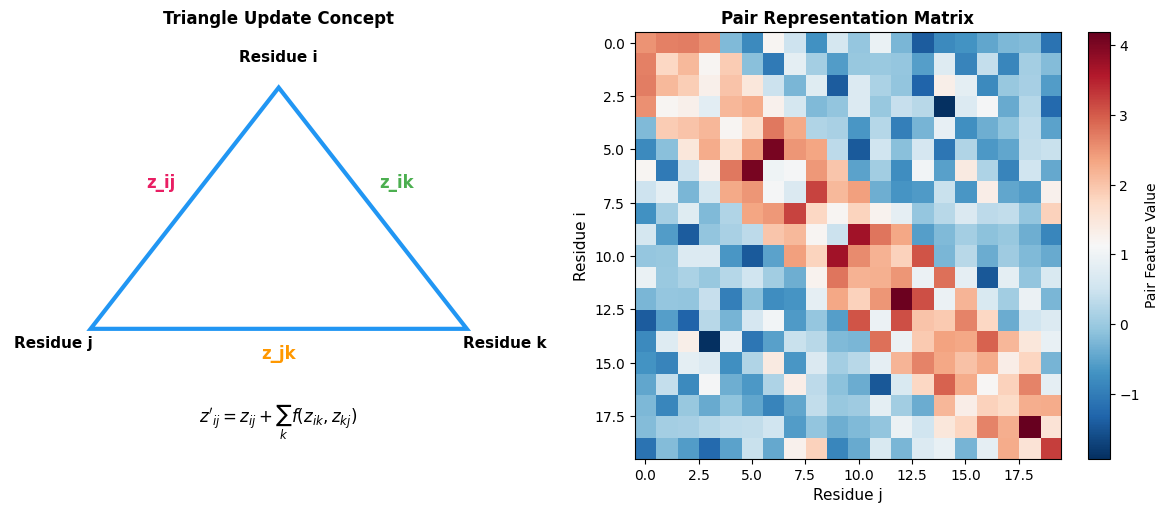


圖片已儲存為 triangle_update_visualization.png


In [29]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 圖 1：三角形更新概念
ax1 = axes[0]
ax1.set_title('Triangle Update Concept', fontsize=12, fontweight='bold')

# 繪製三角形
triangle = plt.Polygon([(0.5, 0.85), (0.15, 0.2), (0.85, 0.2)], 
                       fill=False, edgecolor='#2196F3', linewidth=3)
ax1.add_patch(triangle)

# 頂點標籤
ax1.text(0.5, 0.92, 'Residue i', fontsize=11, ha='center', fontweight='bold')
ax1.text(0.08, 0.15, 'Residue j', fontsize=11, ha='center', fontweight='bold')
ax1.text(0.92, 0.15, 'Residue k', fontsize=11, ha='center', fontweight='bold')

# 邊標籤
ax1.text(0.28, 0.58, 'z_ij', fontsize=12, ha='center', color='#E91E63', fontweight='bold')
ax1.text(0.72, 0.58, 'z_ik', fontsize=12, ha='center', color='#4CAF50', fontweight='bold')
ax1.text(0.5, 0.12, 'z_jk', fontsize=12, ha='center', color='#FF9800', fontweight='bold')

# 更新公式
ax1.text(0.5, -0.05, r"$z'_{ij} = z_{ij} + \sum_k f(z_{ik}, z_{kj})$", 
         fontsize=12, ha='center', style='italic')

ax1.set_xlim(0, 1)
ax1.set_ylim(-0.15, 1)
ax1.axis('off')

# 圖 2：Pair 表示矩陣
ax2 = axes[1]
ax2.set_title('Pair Representation Matrix', fontsize=12, fontweight='bold')

# 繪製一個簡化的 Pair 矩陣
np.random.seed(42)
pair_matrix = np.random.randn(20, 20)
# 讓它對稱並加入一些結構
pair_matrix = (pair_matrix + pair_matrix.T) / 2
for i in range(20):
    for j in range(max(0, i-3), min(20, i+4)):
        pair_matrix[i, j] += 2

im = ax2.imshow(pair_matrix, cmap='RdBu_r', aspect='equal')
ax2.set_xlabel('Residue j', fontsize=11)
ax2.set_ylabel('Residue i', fontsize=11)
plt.colorbar(im, ax=ax2, label='Pair Feature Value')

plt.tight_layout()
plt.savefig('triangle_update_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n圖片已儲存為 triangle_update_visualization.png")

## 12. 總結

本 notebook 實作了 AlphaFold 2 的核心組件：

1. **Input Embedding**：將胺基酸序列轉換為 MSA 和 Pair 表示

2. **MSA Attention**：
   - Row attention：捕捉共演化信號
   - Column attention：捕捉序列內長程依賴

3. **Outer Product Mean**：從 MSA 傳遞資訊到 Pair 表示

4. **Triangle Updates**：
   - Triangle multiplication（outgoing/incoming）
   - Triangle attention（starting/ending）
   - 利用三角不等式約束傳播幾何資訊

5. **Invariant Point Attention (IPA)**：
   - 對 3D 剛體變換不變的注意力機制
   - Structure Module 的核心組件

6. **FAPE Loss**：
   - 在局部座標系中計算誤差
   - 對局部結構品質敏感

### 實際使用注意事項

- 完整的 AlphaFold 2 包含 48 層 Evoformer 和 8 層 Structure Module
- 訓練需要大量計算資源（128 TPU v3）
- 推論也需要 GPU 加速
- 建議使用官方的 ColabFold 或 AlphaFold 資料庫進行蛋白質結構預測